In [47]:
# Create a Spark session (runs locally by default in most notebook setups)
# Ensure Spark uses this notebook's Python interpreter (important on Windows where `python3` may not exist)
import os
import sys

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("EnergyProject")
    .config("spark.pyspark.python", sys.executable)
    .config("spark.pyspark.driver.python", sys.executable)
    .config("spark.executorEnv.PYSPARK_PYTHON", sys.executable)
    .config("spark.executorEnv.PYSPARK_DRIVER_PYTHON", sys.executable)
    .getOrCreate()
)

# Reduce Spark logging noise in notebook output
spark.sparkContext.setLogLevel("ERROR")

In [48]:
# Read the uploaded survey dataset (CSV)
df = spark.read.csv("pakistanenergyaccesshouseholdpanelsurveydata.csv", 
                    header=True, inferSchema=True)

# Preview a few useful columns
df.select("Region", "Districts", "Gender", "SEC").show(5, truncate=False)

+------+---------------------+------+-----+
|Region|Districts            |Gender|SEC  |
+------+---------------------+------+-----+
|NULL  |Bahawalnagar District|2     |SEC C|
|NULL  |NULL                 |NULL  |NULL |
|NULL  |Bhakkar District     |2     |SEC D|
|NULL  |NULL                 |NULL  |NULL |
|NULL  |Bhakkar District     |2     |SEC D|
+------+---------------------+------+-----+
only showing top 5 rows


In [49]:
# Inspect schema inferred by Spark
df.printSchema()

root
 |-- Interview type: string (nullable = true)
 |-- Peri Urban/ Rural: string (nullable = true)
 |-- SEC: string (nullable = true)
 |-- Region: string (nullable = true)
 |-- Districts: string (nullable = true)
 |-- Cultural Belts: string (nullable = true)
 |-- Gender: integer (nullable = true)
 |-- Household Size: integer (nullable = true)
 |-- Housing type you are living: integer (nullable = true)
 |-- Rooms does the house have : integer (nullable = true)
 |-- House rented or owned: integer (nullable = true)
 |-- household composition: integer (nullable = true)
 |-- Education of Head of household: integer (nullable = true)
 |-- Occupation of head of household: integer (nullable = true)
 |-- Do you expect the number of household members living in your home to change in the next 1-2 years?: integer (nullable = true)
 |-- Are you planning to increase the size of your home by adding rooms or spaces that will need lighting in the next 1-2 years?: integer (nullable = true)
 |-- Do you o

In [50]:
df.select("Region").limit(10000).groupBy("Region").count().show()

+-------+-----+
| Region|count|
+-------+-----+
|Karachi| 1662|
|      5|    1|
| Quetta|  456|
|   NULL| 7881|
+-------+-----+



In [51]:
df.filter(df["Is your household connected to the National or Local Mini-Grid?"] == 1).select("Region", "Districts", "Is your household connected to the National or Local Mini-Grid?").limit(20).show(truncate=False)

+------+---------------------+---------------------------------------------------------------+
|Region|Districts            |Is your household connected to the National or Local Mini-Grid?|
+------+---------------------+---------------------------------------------------------------+
|NULL  |Bahawalnagar District|1                                                              |
|NULL  |Bhakkar District     |1                                                              |
|NULL  |Bhakkar District     |1                                                              |
|NULL  |Bhakkar District     |1                                                              |
|NULL  |Bhakkar District     |1                                                              |
|NULL  |Bahawalnagar District|1                                                              |
|NULL  |Bhakkar District     |1                                                              |
|NULL  |Bhakkar District     |1                   

In [52]:
df.limit(10000).createOrReplaceTempView("energy")
spark.sql("SELECT Region, COUNT(*) AS count FROM energy GROUP BY Region").show()

+-------+-----+
| Region|count|
+-------+-----+
|Karachi| 1662|
|      5|    1|
| Quetta|  456|
|   NULL| 7881|
+-------+-----+



In [53]:
# -----------------------------
# Project Deliverables
# - ETL pipeline (extract, transform, load)
# - map / filter / reduce / groupBy examples (RDD + DataFrame)
# - Spark SQL + performance comparison vs pure Python
# - Performance graphs (rendered as ASCII so it works without extra plotting libraries)
# -----------------------------

from pyspark.sql import functions as F
import os
import time
import csv
from collections import defaultdict

DATA_PATH = "pakistanenergyaccesshouseholdpanelsurveydata.csv"

# Column name as it exists in the uploaded dataset
CONNECTED_COL = "Is your household connected to the National or Local Mini-Grid?"

OUTPUT_DIR = "etl_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Dataset:", os.path.abspath(DATA_PATH))
print("Output dir:", os.path.abspath(OUTPUT_DIR))

Dataset: c:\Users\123\Desktop\BCS-VI (A)\Paralled & Distributed Computing\PDC Project\PySpark-vs-Python-Performace-Analysis-main\pakistanenergyaccesshouseholdpanelsurveydata.csv
Output dir: c:\Users\123\Desktop\BCS-VI (A)\Paralled & Distributed Computing\PDC Project\PySpark-vs-Python-Performace-Analysis-main\etl_output


In [54]:
# Basic transformations: select a few columns, trim strings, cast types
df_etl = (
    df.select(
        F.col("Region").alias("region_raw"),
        F.col("Districts").alias("district_raw"),
        F.col(CONNECTED_COL).alias("connected_raw"),
    )
    .withColumn("region", F.trim(F.col("region_raw")))
    .withColumn("district", F.trim(F.col("district_raw")))
    .withColumn("connected_to_grid", F.col("connected_raw").cast("int"))
    .drop("region_raw", "district_raw", "connected_raw")
)

# Fill missing region/district values so grouping is stable
df_etl = (
    df_etl
    .withColumn(
        "region",
        F.when(F.col("region").isNull() | (F.col("region") == ""), F.lit("UNKNOWN")).otherwise(F.col("region")),
    )
    .withColumn(
        "district",
        F.when(F.col("district").isNull() | (F.col("district") == ""), F.lit("UNKNOWN")).otherwise(F.col("district")),
    )
)

# Cache for repeated use in ETL + benchmarking
df_etl.cache()
df_etl.count()

df_etl.show(10, truncate=False)
df_etl.groupBy("connected_to_grid").count().show()


+-------+---------------------+-----------------+
|region |district             |connected_to_grid|
+-------+---------------------+-----------------+
|UNKNOWN|Bahawalnagar District|1                |
|UNKNOWN|UNKNOWN              |NULL             |
|UNKNOWN|Bhakkar District     |1                |
|UNKNOWN|UNKNOWN              |NULL             |
|UNKNOWN|Bhakkar District     |1                |
|UNKNOWN|UNKNOWN              |NULL             |
|UNKNOWN|Bhakkar District     |1                |
|UNKNOWN|UNKNOWN              |NULL             |
|UNKNOWN|Bhakkar District     |1                |
|UNKNOWN|UNKNOWN              |NULL             |
+-------+---------------------+-----------------+
only showing top 10 rows
+-----------------+-----+
|connected_to_grid|count|
+-----------------+-----+
|             NULL| 8463|
|                1| 7011|
|                2| 1451|
+-----------------+-----+



In [55]:
# ETL Pipeline (DataFrame API)
# Extract: df_etl (already built)
# Transform: filter connected households + groupBy to aggregate
df_connected = df_etl.filter(F.col("connected_to_grid") == 1)

df_counts_df = (
    df_connected
    .groupBy("region")
    .count()
    .orderBy(F.desc("count"))
)

df_counts_df.show(50, truncate=False)

# Load: write the aggregated output to disk
# On some Windows setups Spark's Hadoop writer can fail without winutils/hadoop native libs.
# Since this aggregated dataset is small, we collect and write using pure Python for portability.
import json

output_csv = os.path.join(OUTPUT_DIR, "connected_counts_by_region.csv")
output_jsonl = os.path.join(OUTPUT_DIR, "connected_counts_by_region.jsonl")

rows = df_counts_df.collect()

with open(output_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["region", "count"])
    for r in rows:
        writer.writerow([r["region"], int(r["count"])])

with open(output_jsonl, "w", encoding="utf-8") as f:
    for r in rows:
        f.write(json.dumps({"region": r["region"], "count": int(r["count"])}) + "\n")

print("Wrote CSV to:", os.path.abspath(output_csv))
print("Wrote JSONL to:", os.path.abspath(output_jsonl))


+--------+-----+
|region  |count|
+--------+-----+
|UNKNOWN |2656 |
|Multan  |1485 |
|Quetta  |1183 |
|Karachi |985  |
|Peshawar|702  |
+--------+-----+

Wrote CSV to: c:\Users\123\Desktop\BCS-VI (A)\Paralled & Distributed Computing\PDC Project\PySpark-vs-Python-Performace-Analysis-main\etl_output\connected_counts_by_region.csv
Wrote JSONL to: c:\Users\123\Desktop\BCS-VI (A)\Paralled & Distributed Computing\PDC Project\PySpark-vs-Python-Performace-Analysis-main\etl_output\connected_counts_by_region.jsonl


In [56]:
# Map / Filter / Reduce / GroupBy using the DataFrame API (no Python workers required)
# This is more stable on Windows environments where Spark may not find `python3`.

# map: derive a numeric flag we can aggregate
df_mapped = df_etl.select(
    F.col("region"),
    (F.col("connected_to_grid") == 1).cast("int").alias("is_connected"),
)

# filter: keep only connected households
df_filtered = df_mapped.filter(F.col("is_connected") == 1)

# groupBy + reduce: sum the flag per region
df_counts_mfrg = (
    df_filtered
    .groupBy("region")
    .agg(F.sum("is_connected").alias("count"))
    .orderBy(F.desc("count"))
)

df_counts_mfrg.show(50, truncate=False)

# reduce (global): total connected households across all regions
total_connected = df_counts_mfrg.agg(F.sum("count").alias("total_connected")).collect()[0]["total_connected"]
print("Total connected households (all regions):", int(total_connected) if total_connected is not None else 0)


+--------+-----+
|region  |count|
+--------+-----+
|UNKNOWN |2656 |
|Multan  |1485 |
|Quetta  |1183 |
|Karachi |985  |
|Peshawar|702  |
+--------+-----+

Total connected households (all regions): 7011


In [57]:
# Spark SQL version + validation vs DataFrame result
df_etl.createOrReplaceTempView("energy_etl")

df_counts_sql = spark.sql(
    """
    SELECT
      region,
      COUNT(*) AS count
    FROM energy_etl
    WHERE connected_to_grid = 1
    GROUP BY region
    ORDER BY count DESC
    """
)

df_counts_sql.show(50, truncate=False)

# Validate: DataFrame aggregation == SQL aggregation
df_left = df_counts_df.select(F.col("region"), F.col("count").alias("count_df"))
df_right = df_counts_sql.select(F.col("region"), F.col("count").alias("count_sql"))

diff = (
    df_left.join(df_right, on="region", how="full")
    .fillna(0, subset=["count_df", "count_sql"])
    .withColumn("diff", F.col("count_df") - F.col("count_sql"))
    .filter(F.col("diff") != 0)
)

print("Mismatched regions (should be 0 rows):")
diff.show(truncate=False)


+--------+-----+
|region  |count|
+--------+-----+
|UNKNOWN |2656 |
|Multan  |1485 |
|Quetta  |1183 |
|Karachi |985  |
|Peshawar|702  |
+--------+-----+

Mismatched regions (should be 0 rows):
+------+--------+---------+----+
|region|count_df|count_sql|diff|
+------+--------+---------+----+
+------+--------+---------+----+



In [58]:
# Performance comparison: Spark DataFrame vs Spark SQL vs pure Python
# Notes:
# - We benchmark on increasing row limits so the notebook stays responsive.
# - Each Spark benchmark triggers an action (count) to force execution.

def time_spark_dataframe(n_rows: int) -> float:
    t0 = time.perf_counter()
    (
        df_etl.limit(n_rows)
        .filter(F.col("connected_to_grid") == 1)
        .groupBy("region")
        .count()
        .count()
    )
    return time.perf_counter() - t0

def time_spark_sql(n_rows: int) -> float:
    t0 = time.perf_counter()
    df_etl.limit(n_rows).createOrReplaceTempView("energy_bench")
    spark.sql("SELECT region, COUNT(*) AS c FROM energy_bench WHERE connected_to_grid = 1 GROUP BY region").count()
    return time.perf_counter() - t0

def time_pure_python(n_rows: int) -> float:
    t0 = time.perf_counter()
    counts = defaultdict(int)
    with open(DATA_PATH, newline="", encoding="utf-8-sig") as f:
        reader = csv.reader(f)
        header = next(reader)
        try:
            region_idx = header.index("Region")
            conn_idx = header.index(CONNECTED_COL)
        except ValueError as e:
            raise ValueError(f"Required columns not found in CSV header: {e}")

        for i, row in enumerate(reader, start=1):
            if i > n_rows:
                break
            if len(row) <= max(region_idx, conn_idx):
                continue

            region = (row[region_idx] or "UNKNOWN").strip() or "UNKNOWN"
            conn_raw = (row[conn_idx] or "").strip()
            if conn_raw == "1":
                counts[region] += 1

    return time.perf_counter() - t0

# Pick increasing sizes (adjustable)
sizes = [10_000, 50_000, 100_000]

results = []
for n in sizes:
    results.append({
        "rows": n,
        "spark_dataframe_s": time_spark_dataframe(n),
        "spark_sql_s": time_spark_sql(n),
        "pure_python_s": time_pure_python(n),
    })

results


[{'rows': 10000,
  'spark_dataframe_s': 0.22839969999040477,
  'spark_sql_s': 0.14395490000606515,
  'pure_python_s': 0.1752552999969339},
 {'rows': 50000,
  'spark_dataframe_s': 0.17862209999293555,
  'spark_sql_s': 0.16000889999850187,
  'pure_python_s': 0.12356050001108088},
 {'rows': 100000,
  'spark_dataframe_s': 0.14400840000598691,
  'spark_sql_s': 0.20136449999699835,
  'pure_python_s': 0.11890700001094956}]

In [59]:
# Performance graphs (ASCII)
# This avoids extra plotting dependencies and still provides clear visuals.

def ascii_bar(value: float, max_value: float, width: int = 40) -> str:
    if max_value <= 0:
        return ""
    filled = int(round((value / max_value) * width))
    filled = max(0, min(width, filled))
    return "█" * filled + " " * (width - filled)

def print_ascii_chart(results_list):
    max_time = max(max(r["spark_dataframe_s"], r["spark_sql_s"], r["pure_python_s"]) for r in results_list)
    print("rows\tmethod\t\tseconds\tchart")
    for r in results_list:
        for key, label in [
            ("spark_dataframe_s", "Spark DataFrame"),
            ("spark_sql_s", "Spark SQL"),
            ("pure_python_s", "Pure Python"),
        ]:
            v = r[key]
            bar = ascii_bar(v, max_time)
            print(f"{r['rows']}\t{label:<14}\t{v:0.4f}\t{bar}")

print_ascii_chart(results)

# Also print a compact table
for r in results:
    print(f"n={r['rows']}: df={r['spark_dataframe_s']:.4f}s, sql={r['spark_sql_s']:.4f}s, py={r['pure_python_s']:.4f}s")


rows	method		seconds	chart
10000	Spark DataFrame	0.2284	████████████████████████████████████████
10000	Spark SQL     	0.1440	█████████████████████████               
10000	Pure Python   	0.1753	███████████████████████████████         
50000	Spark DataFrame	0.1786	███████████████████████████████         
50000	Spark SQL     	0.1600	████████████████████████████            
50000	Pure Python   	0.1236	██████████████████████                  
100000	Spark DataFrame	0.1440	█████████████████████████               
100000	Spark SQL     	0.2014	███████████████████████████████████     
100000	Pure Python   	0.1189	█████████████████████                   
n=10000: df=0.2284s, sql=0.1440s, py=0.1753s
n=50000: df=0.1786s, sql=0.1600s, py=0.1236s
n=100000: df=0.1440s, sql=0.2014s, py=0.1189s


# Additional Analysis + Interactive Visualizations

This section adds a few extra perspectives on the dataset (region, district, gender, SEC), and interactive performance charts.

Interactive charts are rendered using Vega-Lite (embedded via CDN) so you get tooltips, zooming/panning (where enabled), and legend-based filtering without installing extra Python plotting libraries. If your notebook environment blocks inline scripts, the code also attempts to render charts via the Vega-Lite MIME bundle.


In [60]:
from pyspark.sql import functions as F
import json
import uuid
from IPython.display import HTML, display

def connection_status_expr(col_name: str):
    c = F.col(col_name)
    return (
        F.when(c == 1, F.lit("Connected"))
        .when(c == 2, F.lit("Not connected"))
        .otherwise(F.lit("Unknown/NA"))
    )

top_n = 10

def safe_int(col):
    s = F.trim(col.cast("string"))
    return F.when(s.rlike("^[0-9]+$"), s.cast("int")).otherwise(F.lit(None).cast("int"))

region_connected_top = (
    df_etl
    .withColumn("connection_status", connection_status_expr("connected_to_grid"))
    .filter((F.col("connection_status") == "Connected") & (F.col("region") != "UNKNOWN") & (F.trim(F.col("region")) != ""))
    .groupBy("region")
    .count()
    .orderBy(F.desc("count"))
    .limit(top_n)
)

district_connected_top = (
    df_etl
    .withColumn("connection_status", connection_status_expr("connected_to_grid"))
    .filter((F.col("connection_status") == "Connected") & (F.col("district") != "UNKNOWN") & (F.trim(F.col("district")) != ""))
    .groupBy("district")
    .count()
    .orderBy(F.desc("count"))
    .limit(top_n)
)

overall_connection = (
    df_etl
    .withColumn("connection_status", connection_status_expr("connected_to_grid"))
    .filter(F.col("connection_status") != "Unknown/NA")
    .groupBy("connection_status")
    .count()
)

gender_connection = (
    df.select(
        F.when(F.col("Gender").isNull() | (F.trim(F.col("Gender").cast("string")) == ""), F.lit("UNKNOWN")).otherwise(F.col("Gender").cast("string")).alias("gender"),
        safe_int(F.col(CONNECTED_COL)).alias("connected_to_grid"),
    )
    .withColumn("connection_status", connection_status_expr("connected_to_grid"))
    .filter((F.col("gender") != "UNKNOWN") & (F.trim(F.col("gender")) != "") & (F.col("connection_status") != "Unknown/NA"))
    .groupBy("gender", "connection_status")
    .count()
)

sec_connection = (
    df.select(
        F.when(F.col("SEC").isNull() | (F.trim(F.col("SEC").cast("string")) == ""), F.lit("UNKNOWN")).otherwise(F.col("SEC").cast("string")).alias("sec"),
        safe_int(F.col(CONNECTED_COL)).alias("connected_to_grid"),
    )
    .withColumn("connection_status", connection_status_expr("connected_to_grid"))
    .filter((F.col("sec") != "UNKNOWN") & (F.trim(F.col("sec")) != "") & (F.col("connection_status") != "Unknown/NA"))
    .groupBy("sec", "connection_status")
    .count()
)

def rows_to_dicts(rows):
    out = []
    for r in rows:
        out.append({k: (int(r[k]) if isinstance(r[k], (int, float)) and k in {"count"} else r[k]) for k in r.asDict().keys()})
    return out

def _valid_label(x) -> bool:
    if x is None:
        return False
    s = str(x).strip()
    return s != "" and s.upper() != "UNKNOWN"

data_region = [{"region": r["region"], "count": int(r["count"])} for r in region_connected_top.collect() if _valid_label(r["region"])]
data_district = [{"district": r["district"], "count": int(r["count"])} for r in district_connected_top.collect() if _valid_label(r["district"])]
data_overall = [{"connection_status": r["connection_status"], "count": int(r["count"])} for r in overall_connection.collect() if str(r["connection_status"]).strip() not in {"", "Unknown/NA"}]
data_gender = [{"gender": r["gender"], "connection_status": r["connection_status"], "count": int(r["count"])} for r in gender_connection.collect() if _valid_label(r["gender"]) and str(r["connection_status"]).strip() not in {"", "Unknown/NA"}]
data_sec = [{"sec": r["sec"], "connection_status": r["connection_status"], "count": int(r["count"])} for r in sec_connection.collect() if _valid_label(r["sec"]) and str(r["connection_status"]).strip() not in {"", "Unknown/NA"}]

perf_long = []
speedup_long = []
for r in results:
    n = int(r["rows"])
    baseline = float(r["pure_python_s"])
    for key, label in [
        ("spark_dataframe_s", "Spark DataFrame"),
        ("spark_sql_s", "Spark SQL"),
        ("pure_python_s", "Pure Python"),
    ]:
        sec = float(r[key])
        perf_long.append({"rows": n, "method": label, "seconds": sec, "rows_per_sec": (n / sec) if sec > 0 else None})
    for key, label in [("spark_dataframe_s", "Spark DataFrame"), ("spark_sql_s", "Spark SQL")]:
        sec = float(r[key])
        speedup_long.append({"rows": n, "method": label, "speedup_vs_python": (baseline / sec) if sec > 0 else None})

print("Prepared datasets for interactive charts:")
print("- region top:", len(data_region))
print("- district top:", len(data_district))
print("- overall connection:", len(data_overall))
print("- gender x connection:", len(data_gender))
print("- SEC x connection:", len(data_sec))
print("- performance points:", len(perf_long))

print("\nPreview (non-empty values):")
preview_cols = ["Region", "Districts", "Gender", "SEC", CONNECTED_COL]
df.select(*preview_cols).show(10, truncate=False)
df.select(*[
    F.sum(F.when(F.trim(F.col(c).cast("string")) != "", F.lit(1)).otherwise(F.lit(0))).alias(c)
    for c in preview_cols
]).show(truncate=False)

sample_n = 2000
sample_df = df.limit(sample_n)
candidate_cols = [c for c in df.columns if isinstance(c, str) and c.strip() != ""]
non_empty_exprs = [
    F.sum(F.when(F.trim(F.col(c).cast("string")) != "", F.lit(1)).otherwise(F.lit(0))).alias(c)
    for c in candidate_cols
]
non_empty_counts = sample_df.agg(*non_empty_exprs).collect()[0].asDict()
non_empty_cols = [c for c in candidate_cols if int(non_empty_counts.get(c, 0) or 0) > 0]
print(f"\nNon-empty columns in first {sample_n} rows:", len(non_empty_cols))
print(non_empty_cols)
preview_non_empty = non_empty_cols[: min(12, len(non_empty_cols))]
if preview_non_empty:
    df.select(*preview_non_empty).show(10, truncate=False)

df_etl.filter((F.col("region") != "UNKNOWN") & (F.col("district") != "UNKNOWN") & (F.trim(F.col("region")) != "") & (F.trim(F.col("district")) != "") & F.col("connected_to_grid").isNotNull()) \
    .select("region", "district", "connected_to_grid") \
    .limit(10) \
    .show(10, truncate=False)


Prepared datasets for interactive charts:
- region top: 4
- district top: 10
- overall connection: 2
- gender x connection: 4
- SEC x connection: 11
- performance points: 9

Preview (non-empty values):
+------+---------------------+------+-----+---------------------------------------------------------------+
|Region|Districts            |Gender|SEC  |Is your household connected to the National or Local Mini-Grid?|
+------+---------------------+------+-----+---------------------------------------------------------------+
|NULL  |Bahawalnagar District|2     |SEC C|1                                                              |
|NULL  |NULL                 |NULL  |NULL |NULL                                                           |
|NULL  |Bhakkar District     |2     |SEC D|1                                                              |
|NULL  |NULL                 |NULL  |NULL |NULL                                                           |
|NULL  |Bhakkar District     |2     |SEC D

1. Top Regions

Saved: etl_output\plots\jpg\top_regions_connected.jpg


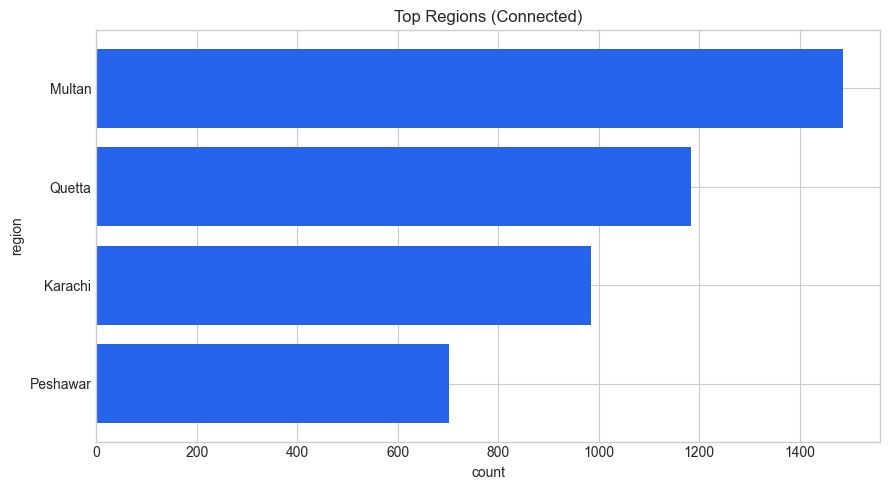

In [61]:
_barh(
    data_region if "data_region" in globals() else [],
    "region",
    "count",
    "Top Regions (Connected)",
    "top_regions_connected"
)

2. Top Districts

Saved: etl_output\plots\jpg\top_districts_connected.jpg


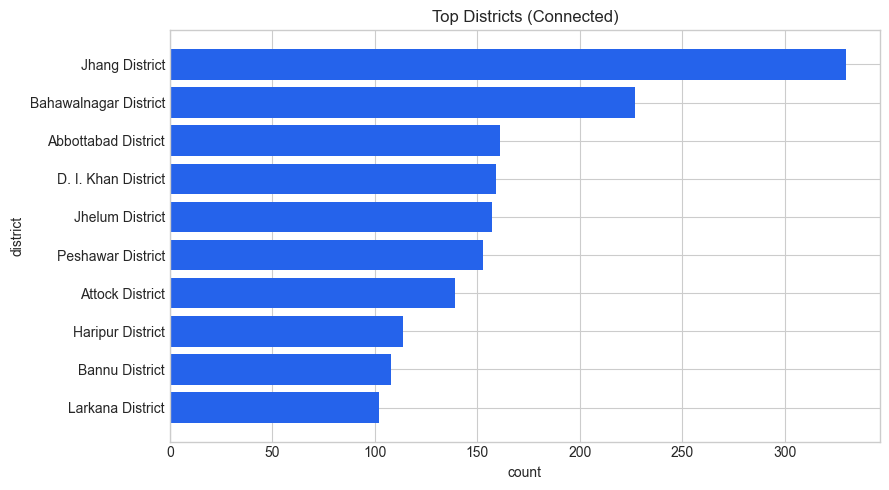

In [62]:
_barh(
    data_district if "data_district" in globals() else [],
    "district",
    "count",
    "Top Districts (Connected)",
    "top_districts_connected"
)

3. Overall Connection Status (Pie)

Saved: etl_output\plots\jpg\overall_connection_status.jpg


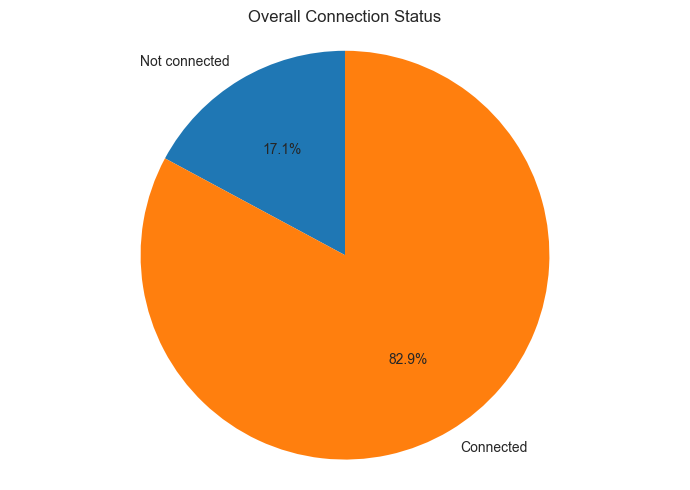

In [63]:
_pie(
    data_overall if "data_overall" in globals() else [],
    "connection_status",
    "count",
    "Overall Connection Status",
    "overall_connection_status"
)

4. Connection by Gender

Saved: etl_output\plots\jpg\connection_by_gender.jpg


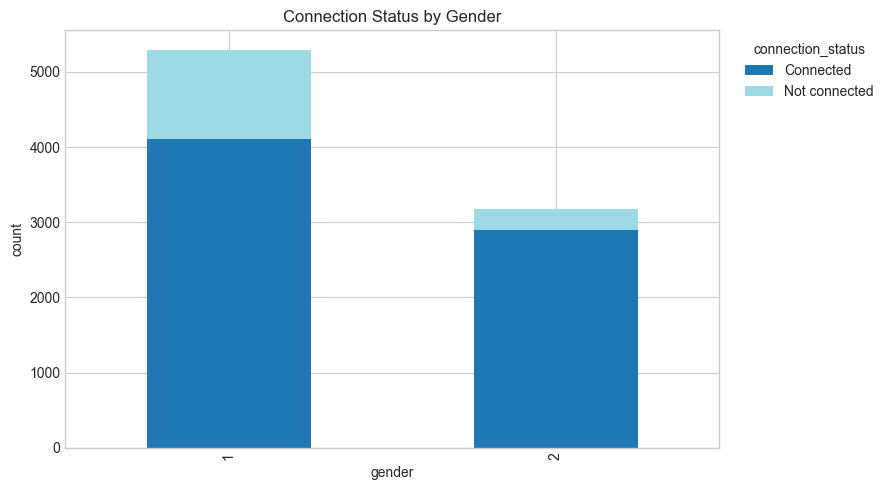

In [64]:
_stacked_bar(
    data_gender if "data_gender" in globals() else [],
    "gender",
    "connection_status",
    "count",
    "Connection Status by Gender",
    "connection_by_gender"
)

5. Connection by SEC

Saved: etl_output\plots\jpg\connection_by_sec.jpg


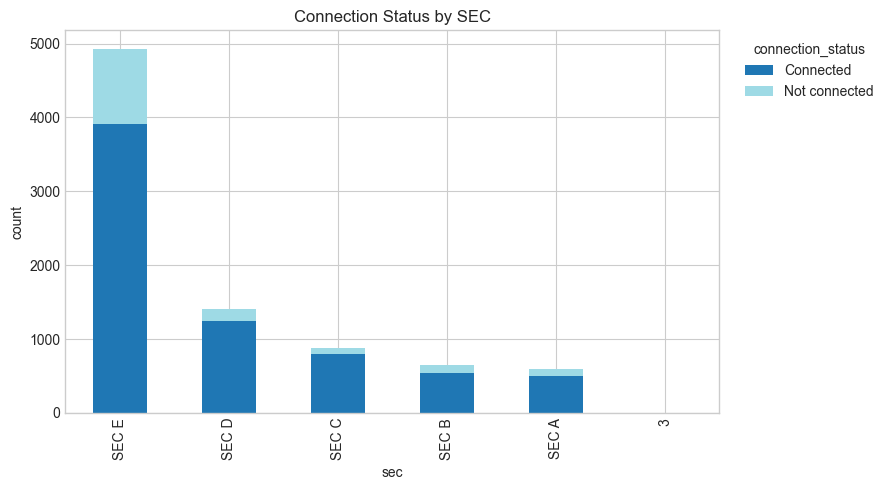

In [65]:
_stacked_bar(
    data_sec if "data_sec" in globals() else [],
    "sec",
    "connection_status",
    "count",
    "Connection Status by SEC",
    "connection_by_sec"
)

6. Performance Speedup

Saved: etl_output\plots\jpg\performance_speedup_vs_python.jpg


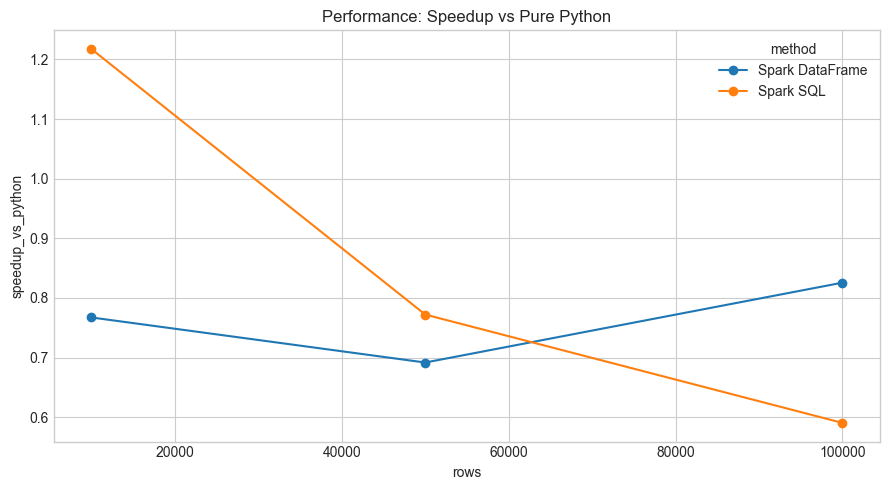

In [66]:
_perf_lines(
    speedup_long if "speedup_long" in globals() else [],
    "rows",
    "speedup_vs_python",
    "method",
    "Performance: Speedup vs Pure Python",
    "performance_speedup_vs_python"
)

7. Area Type

Saved: etl_output\plots\jpg\connection_by_area_type.jpg


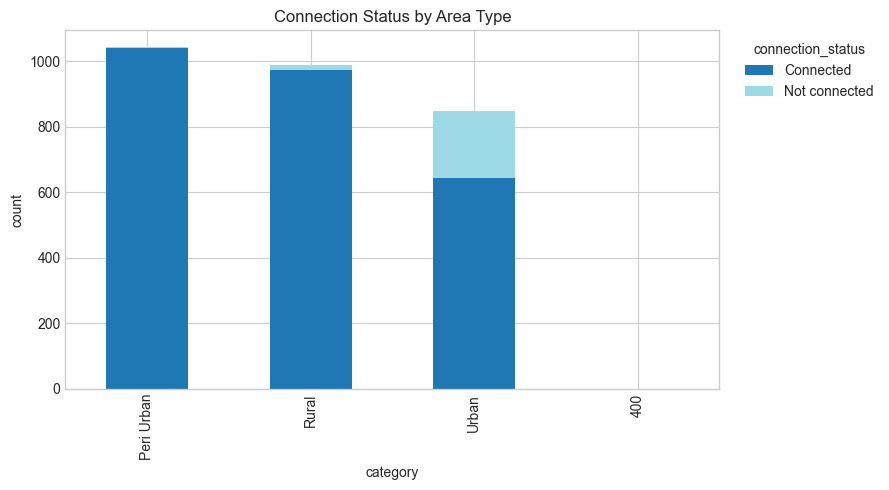

In [67]:
_stacked_bar(
    _connection_by_category(df, "Peri Urban/ Rural", n=8),
    "category",
    "connection_status",
    "count",
    "Connection Status by Area Type",
    "connection_by_area_type"
)

8. Education of Head

Saved: etl_output\plots\jpg\connection_by_head_education.jpg


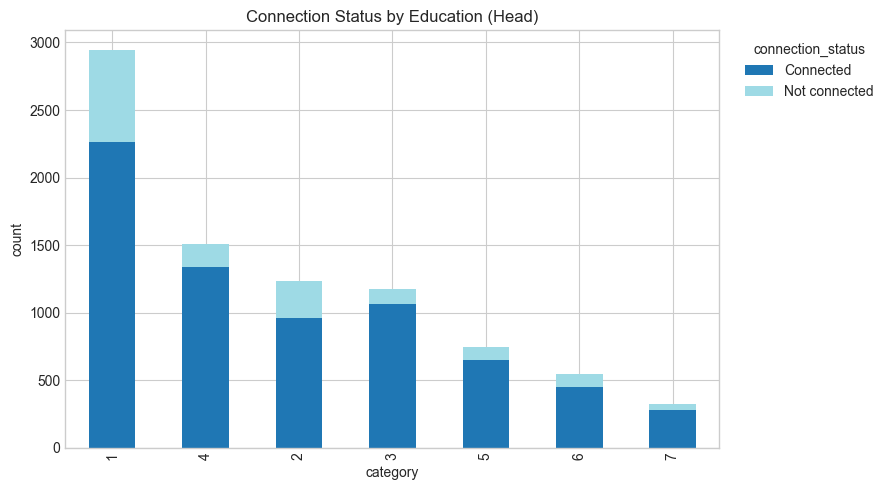

In [68]:
_stacked_bar(
    _connection_by_category(df, "Education of Head of household", n=10),
    "category",
    "connection_status",
    "count",
    "Connection Status by Education (Head)",
    "connection_by_head_education"
)

9. Primary Electricity Source

Saved: etl_output\plots\jpg\primary_electricity_source_top.jpg


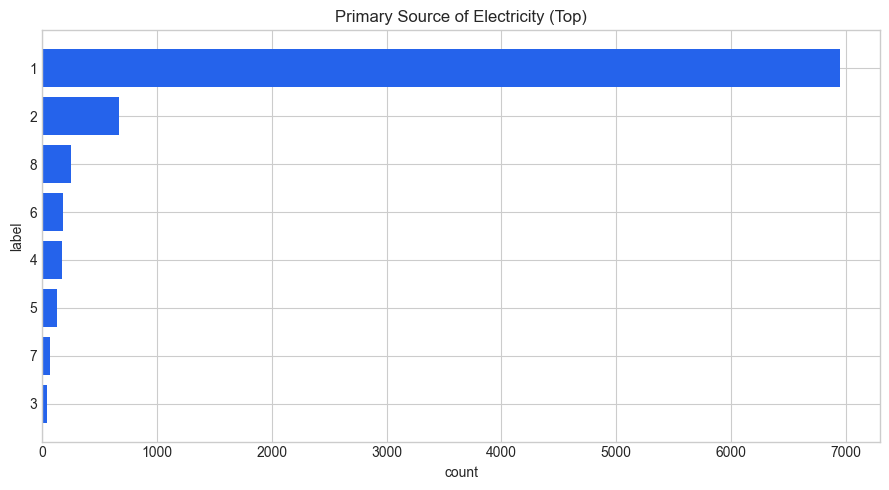

In [69]:
_barh(
    _top_counts(df, "What is the primary source of electricity used in the household? ", "label", n=10),
    "label",
    "count",
    "Primary Source of Electricity (Top)",
    "primary_electricity_source_top"
)

10. Reasons Not Connected

Saved: etl_output\plots\jpg\reasons_not_connected_top.jpg


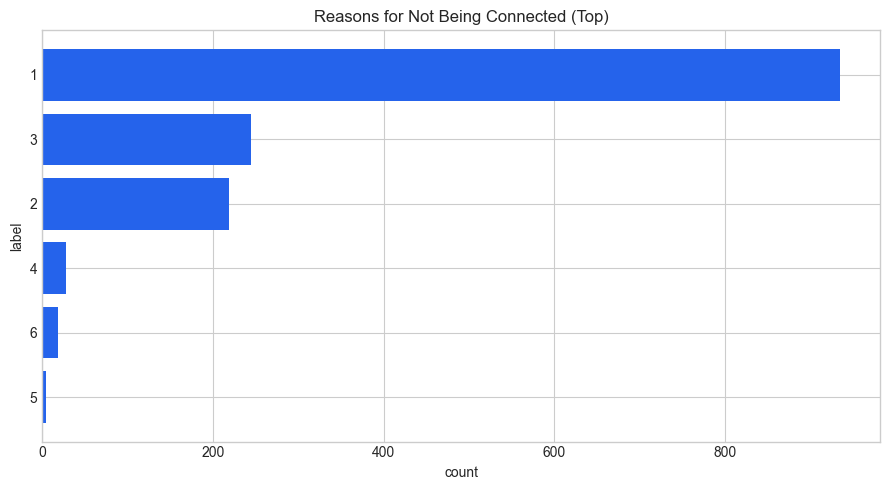

In [70]:
_barh(
    _top_counts(
        df,
        "Why is your household not connected to the grid?",
        "label",
        n=10,
        extra_filter=(safe_int(F.col(CONNECTED_COL)) == 2)
    ),
    "label",
    "count",
    "Reasons for Not Being Connected (Top)",
    "reasons_not_connected_top"
)

11. Household Size Histogram

Saved: etl_output\plots\jpg\household_size_hist.jpg


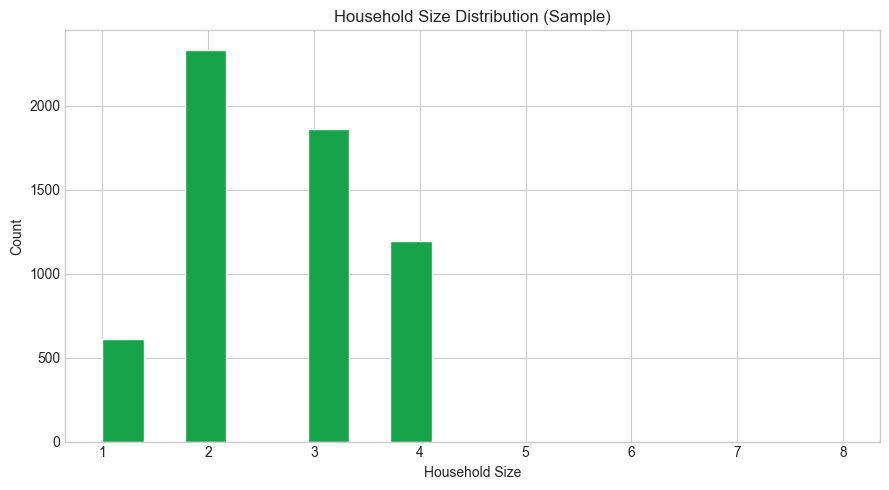

In [71]:
_hist_numeric(
    df,
    "Household Size",
    "Household Size Distribution (Sample)",
    "household_size_hist"
)

12. Monthly Electricity Spend

Saved: etl_output\plots\jpg\monthly_electricity_spend_hist.jpg


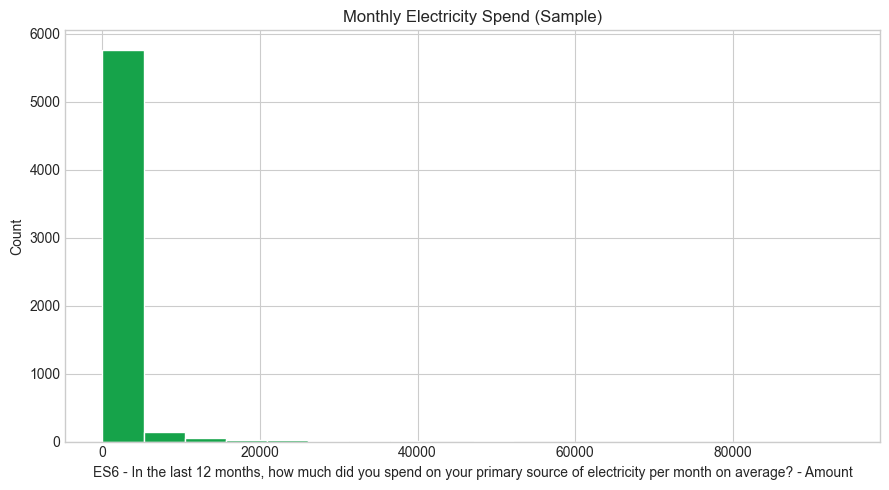

In [72]:
_hist_numeric(
    df,
    "ES6 - In the last 12 months, how much did you spend on your primary source of electricity per month on average? - Amount",
    "Monthly Electricity Spend (Sample)",
    "monthly_electricity_spend_hist"
)

13. Distance to Grid

Saved: etl_output\plots\jpg\distance_to_nearest_connected_km_hist.jpg


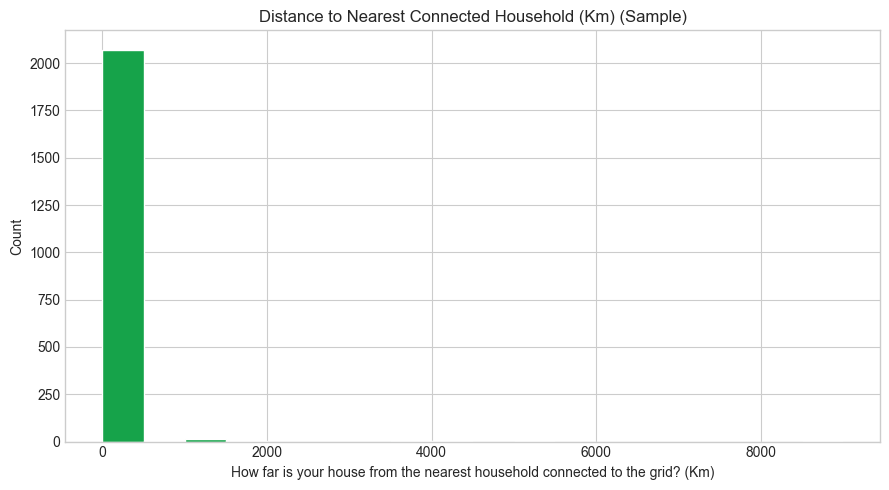

In [73]:
_hist_numeric(
    df,
    "How far is your house from the nearest household connected to the grid? (Km)",
    "Distance to Nearest Connected Household (Km) (Sample)",
    "distance_to_nearest_connected_km_hist"
)

14. Cultural Belt Connection Rate

Saved: etl_output\plots\jpg\pct_connected_by_cultural_belt.jpg


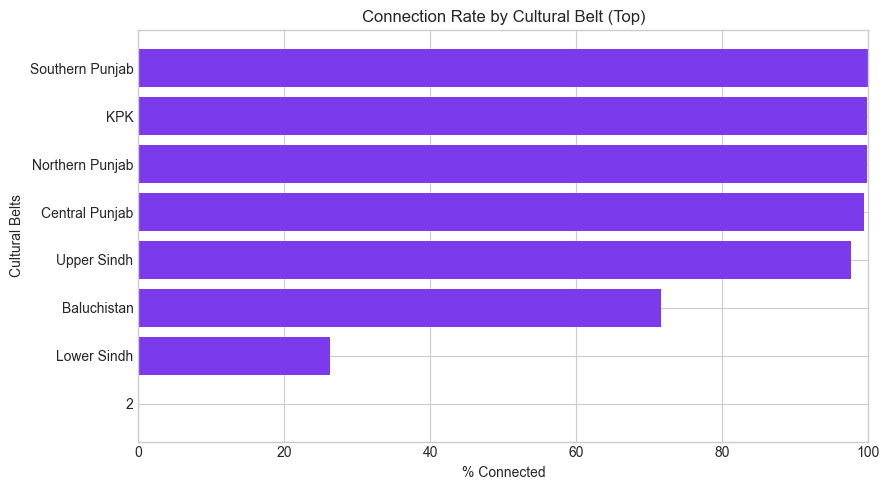

In [74]:
_connection_rate_bar(
    df,
    "Cultural Belts",
    "Connection Rate by Cultural Belt (Top)",
    "pct_connected_by_cultural_belt",
    n=10
)

15. Housing Type

Saved: etl_output\plots\jpg\pct_connected_by_housing_type.jpg


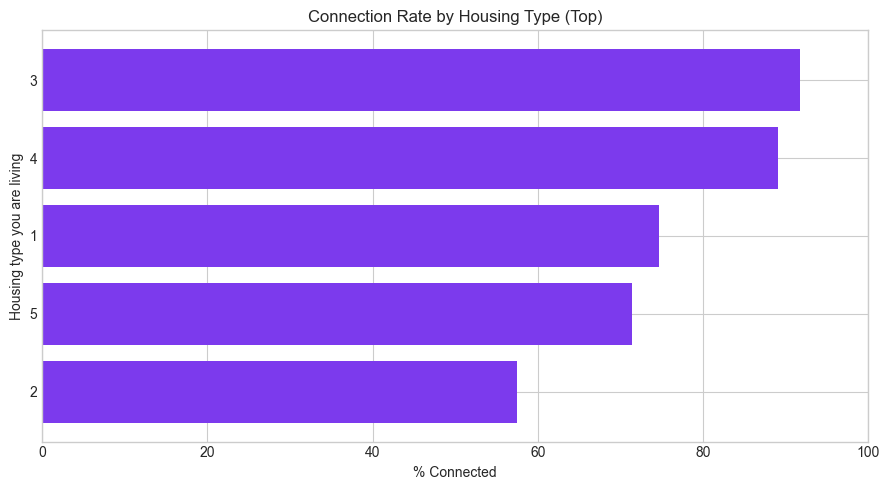

In [75]:
_connection_rate_bar(
    df,
    "Housing type you are living",
    "Connection Rate by Housing Type (Top)",
    "pct_connected_by_housing_type",
    n=10
)

16. Rent vs Own

Saved: etl_output\plots\jpg\pct_connected_by_rent_vs_own.jpg


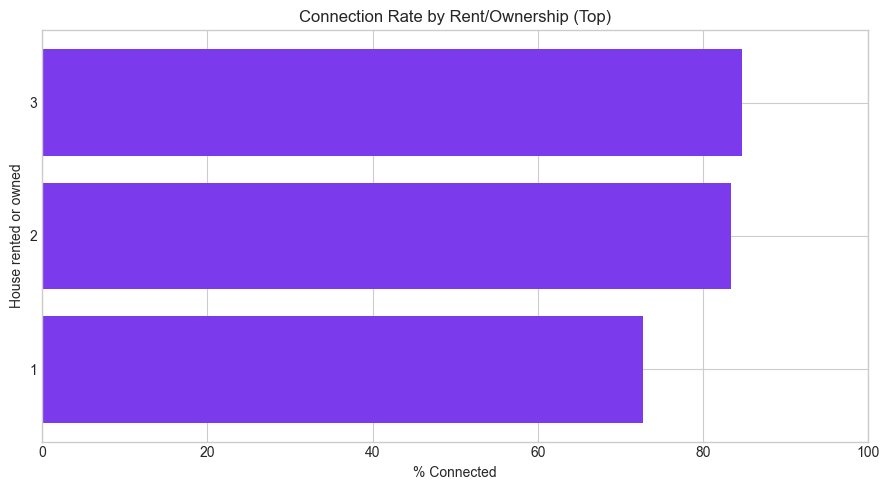

In [76]:
_connection_rate_bar(
    df,
    "House rented or owned",
    "Connection Rate by Rent/Ownership (Top)",
    "pct_connected_by_rent_vs_own",
    n=6
)

17. Distance Boxplot

Saved: etl_output\plots\jpg\distance_km_box_by_status.jpg


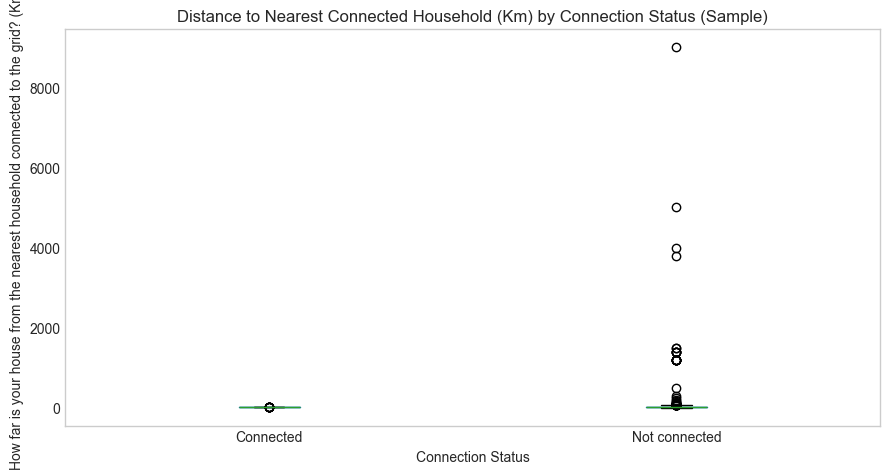

In [77]:
_numeric_boxplot_by_status(
    df,
    "How far is your house from the nearest household connected to the grid? (Km)",
    "Distance to Nearest Connected Household (Km) by Connection Status (Sample)",
    "distance_km_box_by_status"
)

18. Spend Boxplot

Saved: etl_output\plots\jpg\monthly_spend_box_by_status.jpg


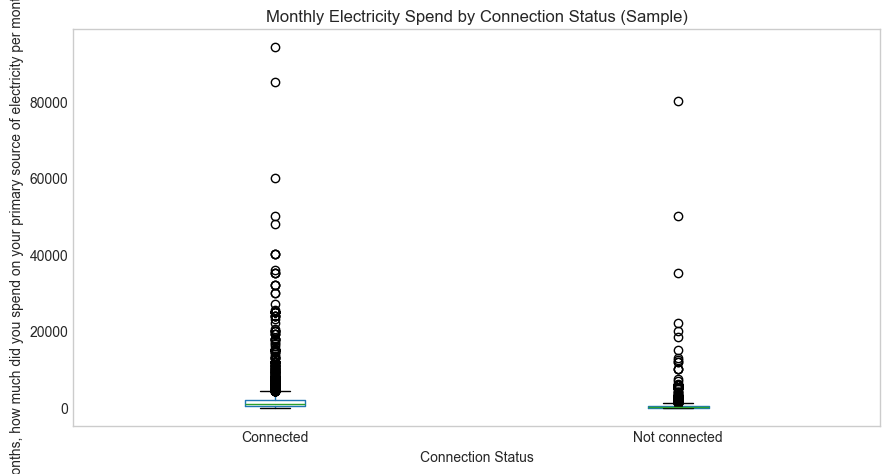

In [78]:
_numeric_boxplot_by_status(
    df,
    "ES6 - In the last 12 months, how much did you spend on your primary source of electricity per month on average? - Amount",
    "Monthly Electricity Spend by Connection Status (Sample)",
    "monthly_spend_box_by_status"
)

19. Scatter Plot

Saved: etl_output\plots\jpg\spend_vs_distance_scatter_by_status.jpg


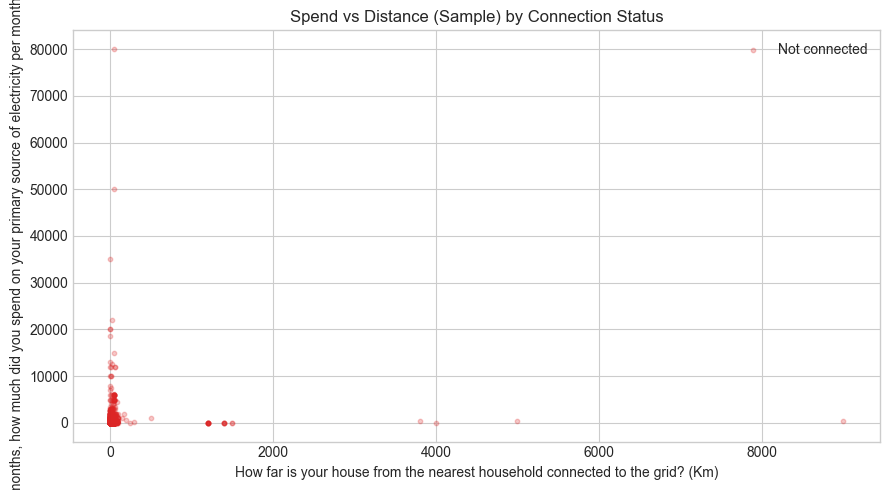

In [79]:
_scatter_by_status(
    df,
    "How far is your house from the nearest household connected to the grid? (Km)",
    "ES6 - In the last 12 months, how much did you spend on your primary source of electricity per month on average? - Amount",
    "Spend vs Distance (Sample) by Connection Status",
    "spend_vs_distance_scatter_by_status"
)

20. Heatmap

Saved: etl_output\plots\jpg\heatmap_culturalbelt_vs_area_pct_connected.jpg


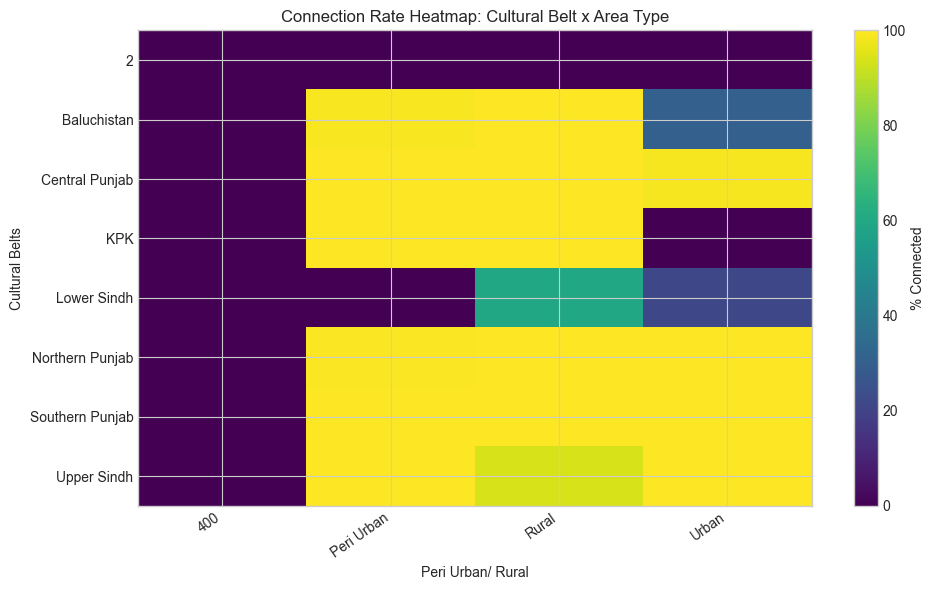

In [80]:
_heatmap_connection_rate(
    df,
    "Cultural Belts",
    "Peri Urban/ Rural",
    "Connection Rate Heatmap: Cultural Belt x Area Type",
    "heatmap_culturalbelt_vs_area_pct_connected",
    row_n=10,
    col_n=6
)

# Final Report: Energy Access Survey (Spark ETL + Benchmarking)

## 1) Objective
- Build an end-to-end ETL pipeline on the household survey dataset.
- Compare Spark DataFrame vs Spark SQL results and validate correctness.
- Benchmark Spark vs a pure-Python baseline.
- Produce multiple unique analyses using **only non-null / non-empty / non-UNKNOWN values**.
- Export plots as **JPG only**.

## 2) Dataset
- Input file: `pakistanenergyaccesshouseholdpanelsurveydata.csv`
- Contains demographics, housing, energy sources, affordability, and connectivity signals.
- Primary connectivity field:
  - `Is your household connected to the National or Local Mini-Grid?`

## 3) ETL Pipeline (Extract → Transform → Load)
**Extract**
- Read the CSV into a Spark DataFrame (schema inference).

**Transform**
- Normalize key fields (trim strings, standardize empty values).
- Convert the connection flag into a typed integer (`connected_to_grid`).
- Derive a readable `connection_status` (Connected / Not connected).
- Filter out invalid labels: empty strings, nulls, and `UNKNOWN`.

**Load**
- Save aggregated region counts to `etl_output/`:
  - `connected_counts_by_region.csv`
  - `connected_counts_by_region.jsonl`

## 4) Functional Transformations (map / filter / reduce / groupBy)
- **map**: derive `is_connected` from `connected_to_grid`.
- **filter**: keep only valid records and/or connected households.
- **groupBy**: aggregate by region/district/category.
- **reduce**: sum within groups and compute totals.

## 5) Spark SQL vs DataFrame Validation
- A Spark SQL aggregation is executed on the same cleaned table.
- A mismatch check compares SQL vs DataFrame results and expects 0 differences.

## 6) Visual Analytics (JPG Only)
All plots are saved to: `etl_output/plots/jpg/`.

**Coverage & Ranking**
- Top connected regions / districts
- Overall connection status split

**Equity & Demographics**
- Connection by gender
- Connection by SEC
- Connection by peri-urban vs rural
- Connection by education of head of household

**Connection Rate (% Connected)**
- % connected by cultural belt
- % connected by housing type
- % connected by rent vs ownership

**Numeric Distributions & Relationships**
- Household size distribution
- Monthly electricity spend distribution
- Distance to nearest connected household distribution
- Boxplots: distance/spend by connection status
- Scatter: spend vs distance by connection status

**2D Study (Heatmap)**
- Cultural belt × peri-urban/rural: % connected

## 7) Performance Benchmarking
- Compared methods:
  - Spark DataFrame aggregation
  - Spark SQL aggregation
  - Pure Python CSV scanning
- Performance charts are exported as JPGs.

## 8) Notes / Limitations
- Benchmark timings vary with machine resources and Spark warm-up overhead.
- Some charts use sampling (`limit(n)`) for notebook responsiveness on very large datasets.


In [81]:
# Final testing cell
# Goal: verify the ETL output files exist and the main aggregations agree.

import os
from pyspark.sql import functions as F

if "df_counts_df" not in globals():
    df_counts_df = (
        df_etl
        .filter(F.col("connected_to_grid") == 1)
        .groupBy("region")
        .count()
        .orderBy(F.desc("count"))
    )

if "df_counts_sql" not in globals():
    df_etl.createOrReplaceTempView("energy_etl")
    df_counts_sql = spark.sql(
        "SELECT region, COUNT(*) AS count FROM energy_etl WHERE connected_to_grid = 1 GROUP BY region ORDER BY count DESC"
    )

if "df_counts_mfrg" not in globals():
    df_mapped = df_etl.select(
        F.col("region"),
        (F.col("connected_to_grid") == 1).cast("int").alias("is_connected"),
    )
    df_counts_mfrg = (
        df_mapped
        .filter(F.col("is_connected") == 1)
        .groupBy("region")
        .agg(F.sum("is_connected").alias("count"))
        .orderBy(F.desc("count"))
    )

# 1) Verify output artifacts were created
expected_csv = os.path.join(OUTPUT_DIR, "connected_counts_by_region.csv")
expected_jsonl = os.path.join(OUTPUT_DIR, "connected_counts_by_region.jsonl")

assert os.path.exists(expected_csv), f"Missing ETL output: {expected_csv}"
assert os.path.exists(expected_jsonl), f"Missing ETL output: {expected_jsonl}"

# 2) Verify DataFrame vs SQL aggregation has no mismatches
df_left_test = df_counts_df.select(F.col("region"), F.col("count").alias("count_df"))
df_right_test = df_counts_sql.select(F.col("region"), F.col("count").alias("count_sql"))

diff_test = (
    df_left_test.join(df_right_test, on="region", how="full")
    .fillna(0, subset=["count_df", "count_sql"])
    .withColumn("diff", F.col("count_df") - F.col("count_sql"))
    .filter(F.col("diff") != 0)
)

assert diff_test.count() == 0, "DataFrame vs SQL mismatch detected"

# 3) Verify functional-demo aggregation equals ETL aggregation (same region counts)
mismatch_mfrg = (
    df_counts_df.select("region", F.col("count").alias("count_etl"))
    .join(df_counts_mfrg.select("region", F.col("count").alias("count_mfrg")), on="region", how="full")
    .fillna(0, subset=["count_etl", "count_mfrg"])
    .withColumn("diff", F.col("count_etl") - F.col("count_mfrg"))
    .filter(F.col("diff") != 0)
)

assert mismatch_mfrg.count() == 0, "ETL vs map/filter/reduce/groupBy mismatch detected"

# 4) Sanity-check benchmarking results structure
if "results" in globals():
    assert isinstance(results, list) and len(results) > 0, "Benchmark results are missing"
    for r in results:
        assert "rows" in r and "spark_dataframe_s" in r and "spark_sql_s" in r and "pure_python_s" in r
else:
    print("Benchmark results not found; run the benchmarking cell to populate 'results'.")

print("ALL TESTS PASSED")


ALL TESTS PASSED
